<a href="https://colab.research.google.com/github/zhangtaira71/house-prices/blob/main/Permutation_Importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(1460, 81)
Missing Values:
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBath       0
GarageArea      0
TotalArea       0
HouseAge        0
LotArea         0
OverallCond     0
TotRmsAbvGrd    0
Fireplaces      0
dtype: int64
Best Params: {'depth': 5, 'iterations': 500}
Best MAE: 16960.26329768412
     Feature  Importance  Importance_%
   TotalArea   27.420125     27.420125
 OverallQual   22.182115     22.182115
    HouseAge   14.201649     14.201649
   GrLivArea    6.795665      6.795665
  GarageArea    6.383890      6.383890
     LotArea    5.869221      5.869221
  Fireplaces    5.569119      5.569119
  GarageCars    4.551912      4.551912
 OverallCond    3.778341      3.778341
TotRmsAbvGrd    1.723611      1.723611
   TotalBath    1.524351      1.524351
         Feature    Importance
5      TotalArea  18757.227257
0    OverallQual  12088.901538
6       HouseAge  11916.041914
1      GrLivArea   4534.433560
8    OverallCond   3756.888843
7        LotArea   2429.227260
10  

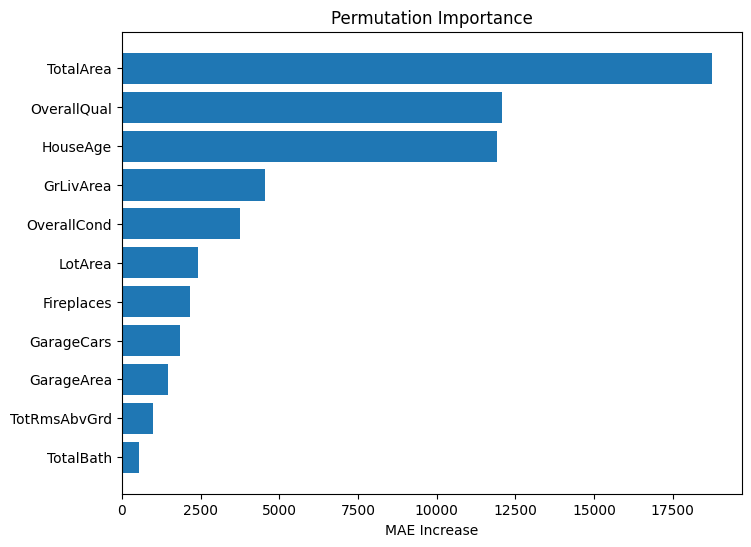

         Feature  CatBoost_Importance  Importance_%  Permutation_Importance
0      TotalArea            27.420125     27.420125            18757.227257
1    OverallQual            22.182115     22.182115            12088.901538
2       HouseAge            14.201649     14.201649            11916.041914
3      GrLivArea             6.795665      6.795665             4534.433560
4     GarageArea             6.383890      6.383890             1466.965391
5        LotArea             5.869221      5.869221             2429.227260
6     Fireplaces             5.569119      5.569119             2155.856594
7     GarageCars             4.551912      4.551912             1842.495010
8    OverallCond             3.778341      3.778341             3756.888843
9   TotRmsAbvGrd             1.723611      1.723611              982.985805
10     TotalBath             1.524351      1.524351              547.986193


In [5]:
from xgboost import XGBRegressor
import pandas as pd

url = "https://raw.githubusercontent.com/zhangtaira71/house-prices/main/train.csv"

train = pd.read_csv(url)

train.head()

print(train.shape)

# print(train.columns)

train["TotalArea"] = (
    train["GrLivArea"]
    + train["TotalBsmtSF"]
)

train["HouseAge"] = (
    2026 - train["YearBuilt"]
)

train["TotalBath"] = (
    train["FullBath"]
    + train["HalfBath"] * 0.5
)

features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBath',
    'GarageArea',
    'TotalArea',
    'HouseAge',
    'LotArea',
    'OverallCond',
    'TotRmsAbvGrd',
    'Fireplaces'
]

missing = (
    train[features]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

print("Missing Values:")
print(missing)

X = train[features]
# y = train['SalePrice']

y = train["SalePrice"]

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import GridSearchCV

!pip install catboost -q

from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
import pandas as pd

model = CatBoostRegressor(
    random_state=42,
    verbose=0
)

param_grid = {
    "depth": [3, 5, 8],
    "iterations": [100, 200, 500]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error"
)

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best MAE:", -grid.best_score_)

best_model = grid.best_estimator_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df["Importance_%"] = (
    importance_df["Importance"]
    / importance_df["Importance"].sum()
    * 100
)

print(importance_df.to_string(index=False))

from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_valid,
    y_valid,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_df = pd.DataFrame({
    "Feature": X_valid.columns,
    "Importance": result.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

print(perm_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(
    perm_df["Feature"],
    perm_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Permutation Importance")
plt.xlabel("MAE Increase")

plt.show()

comparison_df = importance_df.merge(
    perm_df,
    on="Feature"
)

comparison_df = comparison_df.rename(
    columns={
        "Importance_x": "CatBoost_Importance",
        "Importance_y": "Permutation_Importance"
    }
)

print(comparison_df)
